In [1]:
# Imports
import torch
import torch.nn as nn 
from torch.nn import MSELoss, L1Loss, BCELoss, CrossEntropyLoss
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random 

SEED=42
def seed_everything(seed):
    random.seed(seed) # set seed for random
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True 
    torch.backends.cudnn.benchmark = False
seed_everything(SEED)


# Fits an exponential curve f(x) = ae^(bx) using SSE loss
# (x1,y1).         ln y = bx+ln a --> t1=b, t2= ln a,  y'=ln y
#         [x1, 1][t1]= [y1]
#         [x2, 1][t2]  [y2]
#         [x3, 1]
def fit_exp(points: np.ndarray):
    # Put into form
    one = np.ones( (points.shape[0],1) )
    X =  points[:,0].reshape(-1,1)
    X = np.concat([X,one] , axis=1)
    y= np.log(points[:,1]).reshape(-1,1)

    t = np.linalg.inv(X.T @ X) @ X.T @ y 
    b = t[0][0]
    a = np.exp(t[1][0])
    return (a,b)


C:\Users\bmlmo\AppData\Local\Temp\ipykernel_21968\1443950075.py:80: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  curr_loss += float(loss)


loss1= 0.3530179560184479
after------------------------------
loss2= 0.033119477331638336


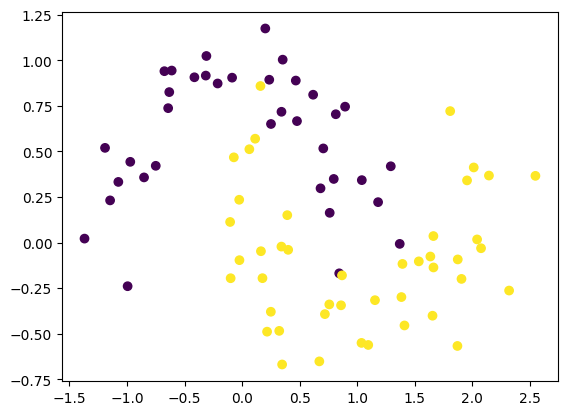

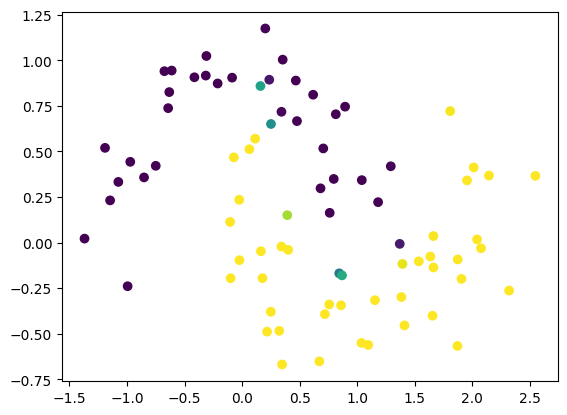

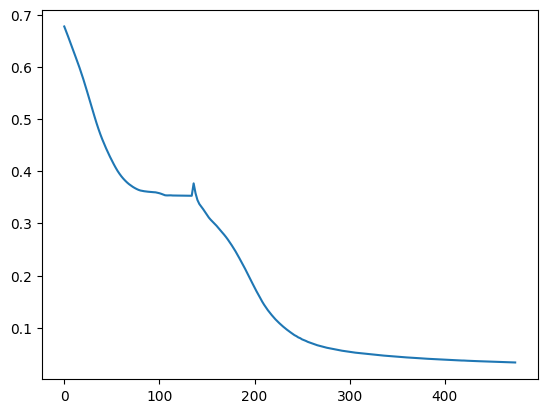

In [2]:
seed_everything(SEED)


# Generate dataset
X, y = make_moons(n_samples=100, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Convert to pytorch tensor
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)


class MLP(nn.Module):
    # linear_idx = The indices that linear layers are located at.
    def __init__(self, in_dim, out_dim, hidden=(2,2,2), activation="relu", dropout=0.0):
        super().__init__()
        # 1. Choose the activation function
        act_fn_map = {"relu": nn.ReLU, "sigmoid": nn.Sigmoid, "tanh": nn.Tanh}
        act_fn = act_fn_map[activation]

        # 2. Create the layers
        layers = []; linear_idx = []
        i=0 # current layer index
        prev_layer_size = in_dim 
        for curr_layer_size in hidden: 
            fci = nn.Linear(prev_layer_size, curr_layer_size) # fully connected linear layer
            acti = act_fn()
            linear_idx.append(i);  layers.append(fci);  i+=1 # Add linear layer
            layers.append(acti); i+=1 # Add activation layer
            prev_layer_size = curr_layer_size 

        linear_idx.append(i); fci = nn.Linear(prev_layer_size,  out_dim); i+=1
        acti = nn.Sigmoid()
        layers.append(fci); layers.append(acti)

        self.network = nn.Sequential(*layers)
        self.linear_idx = linear_idx

        # Measuring the loss
        self.loss_history = []# The complete loss history of the network, including losses from parent networks (big and expensive so is opt-in)
        self.loss_store_rate = 2 # The rate at which we store the loss, used so we don't end up storing too much
        self.final_loss_history = [] # just the final losses from the network history

    def forward(self, x):
        y_hat = self.network(x)
        return y_hat 
    
    # cfg:  {max_epoch, 
    #        loss = the loss function used ("MSE" or "MAE" or "BCE"),
    #        lr = initial learning rate
    #        patience = 20  , max no.iterations it is allowed to not improve for}
    def train_model(self, cfg, X_tr, y_tr, store_loss=True):
        max_epoch = cfg["max_epoch"]

        criterion = MSELoss()
        if cfg["criterion"] == "MSE": criterion = MSELoss()
        elif cfg["criterion"] == "MAE": criterion = L1Loss()
        elif cfg["criterion"] == "BCE": criterion= BCELoss()

        patience = cfg["patience"] # Max number of epochs for which training loss can't improve

        optimizer = torch.optim.Adam(self.parameters(), lr=cfg["lr"])
        
        epoch =0 
        final_loss = 1_000_000
        prev_loss = np.inf; nconsecutive_bad_epochs = 0 
        while epoch < max_epoch and nconsecutive_bad_epochs < patience:
            self.train()
            epoch += 1
            curr_loss = 0.0 

            #------------------------
            # prediction = torch.flatten( self(X_tr) )
            prediction = self(X_tr)
            loss = criterion(prediction, y_tr)
            loss.backward()
            curr_loss += float(loss)
            final_loss = curr_loss

            #------------------------

            optimizer.step()
            optimizer.zero_grad() # Reset gradients so it doesn't accumulate
            
            # if store_loss:
            if store_loss and epoch % self.loss_store_rate == 0: # every 10 epochs, store the loss
                self.loss_history.append(curr_loss)

            nconsecutive_bad_epochs = nconsecutive_bad_epochs+1 if prev_loss-curr_loss < 0.0001 else 0

            # if nconsecutive_bad_epochs >= patience:
            #     print("early stop at epoch=", epoch)

            prev_loss = curr_loss
        self.final_loss_history.append(final_loss)
        
        return final_loss 

    #* Growing utilities *#
    # Adds a new unit to the end of the specified layer, with weight=1 for incoming weights
    def add_unit(self, layer):
        # 1) Add weights & bias going into the new neuron
        # print("prev")
        linear_layer = self.linear_idx[layer]
        # print("layer before=", self.network[linear_layer])

        prev_weights = self.network[linear_layer].weight[:]
        prev_bias    = self.network[linear_layer].bias[:]

        assert(layer+1 < len(self.linear_idx)) # An attempt to add a new output - may want it but strange
        

        # new_in_weights = torch.zeros(1,prev_weights.shape[1]) # torch.tensor([[1,2,3,4,5]])
        new_in_weights =  torch.from_numpy( np.random.normal(0., 1, size=(1, prev_weights.shape[1])) ) 

        new_bias = torch.tensor([0.]) #torch.tensor([69.])

        result_w = torch.concatenate((prev_weights, new_in_weights), axis=0)
        # print("weights_before=", prev_weights, prev_weights.shape) # (out_weights, in_weights)
        # print("-->", result_w)
        result_b = torch.concatenate( (prev_bias, new_bias), axis=0 )
        # print("bias before=", prev_bias)
        # print("-->", result_b)

        # Add the new weights to the network
        # a) Create a new nn.Linear with the new size
        with torch.no_grad():
            in_dim = prev_weights.shape[1]; out_dim  = prev_weights.shape[0]  # old Dimensions
            l = nn.Linear(in_dim, out_dim+1)
            l.weight[:] = result_w 
            l.bias[:] = result_b 
            self.network[linear_layer] = l 

        # 2) Add weights and bias going out of the new neuron
        # next_layer = self.linear_idx[layer+1]
        if layer+1 < len(self.linear_idx):
            linear_layer =self.linear_idx[layer+1]
            next_weights = self.network[linear_layer].weight[:]
            next_bias = self.network[linear_layer].bias[:] # Idk if bias changes
            in_dim = next_weights.shape[1]; out_dim = next_weights.shape[0]

            # Make the new weights via a random gaussian distribution
            out_weights = torch.from_numpy( np.random.normal(size=(out_dim,1)) ) 

            # Add the column
            with torch.no_grad():
                result_w = torch.concatenate( (next_weights, out_weights), axis=1)
                l = nn.Linear(in_dim+1, out_dim)
                l.weight[:] = result_w
                l.bias[:] = next_bias # bias is unchanged
                self.network[linear_layer] = l 

    # eg layers=[1,2,1] adds 2 nodes to layer 1 and 1 node to layer 2.
    def add_units(self, layers: np.ndarray):
        for layer_num in layers:
            # print("layer_num=", layer_num)
            self.add_unit(layer_num)



    # Calculates the f-score of the MLP by modelling a curve from the recent previous losses
    def get_fscore(self, max_iterations, n_samples=4):
        # _losses= [3,5, 2,1,1] 
        _losses = self.final_loss_history
        num_samples = n_samples # take the 4 most recent samples to model it
        losses = np.array(_losses)
        samples = losses[-num_samples: ]

        # Get into format [ [x,y], [x,y] ]
        x = np.arange(len(losses))[-num_samples: ]
        points = np.column_stack( (x,samples) )

        a,b = fit_exp(points)
        #-------------------- Method1: When it has converged
        #------------------- Method2: predict its score after the max no.iterations (simpler)
        # current_x = x[x.shape[0]-1]; future_x = current_x + 5 # Alternatively maybe just use what its value will be after some turns
        f_score = a*np.exp(b*max_iterations)
        return float(f_score)

    
    #--- Visualisation -----
    def plot_loss(self):
        losses =self.loss_history
        plt.plot(range(0, len(losses)*self.loss_store_rate, self.loss_store_rate), losses)
        plt.show()
    def plot_final_loss(self):
        losses =self.final_loss_history
        plt.plot(range(0, len(losses)), losses)
        plt.show()
        
    def print_weights(self):   
        i =0
        for layer in self.linear_idx:
            print("Layer", i); i+=1
            print("w=", self.network[layer].weight[:])
            print("b=", self.network[layer].bias[:])
            
        


def test():
    # Test it works
    model_test = MLP(in_dim=2, hidden=(2,2),out_dim=1, dropout=0.0)

    with torch.no_grad():
        print(model_test.network[0].weight)
        # Layer1 
        model_test.network[0].weight[:] = torch.tensor([ [5.,4.], [3., 1.]])
        model_test.network[0].bias[:] = torch.tensor([0.,0.])

        # Layer2 
        model_test.network[2*1].weight[:] = torch.tensor(  [[3., 5.], [3., 1.]] )
        model_test.network[2*1].bias[:] = torch.tensor( [1., 0.])

        # Layer3
        model_test.network[2*2].weight[:] = torch.tensor( [ [2., 4.] ] )
        model_test.network[2*2].bias[:] = torch.tensor( [0.])

        result = model_test(torch.tensor([1., 1.]))

        


        # print(model_test)
        # print(result)  # Should be 220
# test()

cfg = {"max_epoch": 500, "criterion": "BCE", "lr": 0.01, "patience": 20}
model = MLP(in_dim=2, hidden=(2,3), out_dim=1)  # hidden=(50,2)
# print("model=", model)

loss1= model.train_model(cfg, X_train, y_train)
print("loss1=", loss1)
# print(model.network)
# model.print_weights()

# pred = model.forward(X_train).detach().numpy()
# pred = (pred > 0.5).astype(int) # Convert to either 1 or 0

# print("linear_idx=", model.linear_idx)
print("after------------------------------")
model.add_unit(0); model.add_unit(0);  model.add_unit(0); model.add_unit(1)
model.add_unit(0); model.add_unit(0);  model.add_unit(0);
model.add_unit(0); model.add_unit(0);  model.add_unit(0);
# model.print_weights()

loss2 = model.train_model(cfg, X_train, y_train)
print("loss2=", loss2)






# model.print_weights()
# model.print_weights()
# print("out=", model.forward(torch.tensor([1., 1.])) )
# pred = model.forward(X_train).detach().numpy()

def test_make_moons(model, X_train, y_train):
    pred = model.forward(X_train).detach().numpy()

    # Visualize make_moons test
    plt.scatter(X_train[:,0],X_train[:,1], c=y_train, cmap="viridis") # c is color
    plt.show()
    plt.scatter(X_train[:,0], X_train[:,1], c=pred, cmap="viridis")
    plt.show()

test_make_moons(model, X_train, y_train)

model.plot_loss()


# import copy  
# model2 = copy.deepcopy(model)
# print(model.loss_history)




i= 0
frontier= 1
frontier= [1.0]
loss history= [0.6884335279464722, 0.6202845573425293]
fscore= 0.6202845573425293
[2 0 0 1 1] loss= 0.6202845573425293
loss history= [0.6884335279464722, 0.6881886720657349]
fscore= 0.6881886720657349
[3 0 1 2 0] loss= 0.6881886720657349

i= 1
frontier= 2
frontier= [0.6202845573425293, 0.6881886720657349]
loss history= [0.6884335279464722, 0.6202845573425293, 0.257352352142334]
fscore= 0.257352352142334
[2 2 0 1 1] loss= 0.257352352142334
loss history= [0.6884335279464722, 0.6202845573425293, 0.605942964553833]
fscore= 0.605942964553833
[0 0 0 3 0] loss= 0.605942964553833

i= 2
frontier= 3
frontier= [0.257352352142334, 0.6881886720657349, 0.605942964553833]
loss history= [0.6884335279464722, 0.6202845573425293, 0.257352352142334, 0.21306867897510529]
fscore= 0.21306867897510529
[3 1 0 2 3] loss= 0.21306867897510529
loss history= [0.6884335279464722, 0.6202845573425293, 0.257352352142334, 0.17357736825942993]
fscore= 0.17357736825942993
[2 2 0 2 3] loss

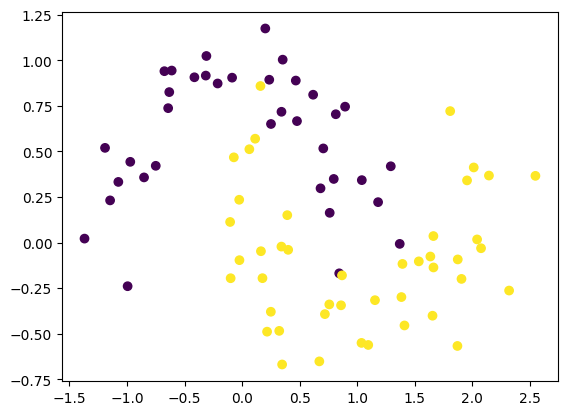

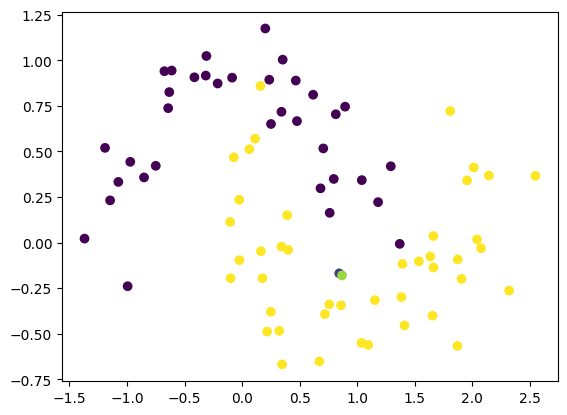

Final loss= 0.004700999241322279
loss history= [0.7612320184707642, 0.7536963224411011, 0.7458100318908691, 0.7387439012527466, 0.7325871586799622, 0.7271050214767456, 0.7219430804252625, 0.7170839905738831, 0.712557315826416, 0.7083901762962341, 0.7046061754226685, 0.7012243866920471, 0.698257565498352, 0.6957113742828369, 0.693583071231842, 0.6918600797653198, 0.6905199885368347, 0.6895300149917603, 0.6888483762741089, 0.6884255409240723, 0.6882075667381287, 0.6881395578384399, 0.688168466091156, 0.6882486343383789, 0.6883428692817688, 0.6884251832962036, 0.688480019569397, 0.6885017156600952, 0.6884921193122864, 0.6884576082229614, 0.7321405410766602, 0.7243509292602539, 0.7185345888137817, 0.7128238081932068, 0.7079724073410034, 0.7027217745780945, 0.6975351572036743, 0.6923171877861023, 0.6878286600112915, 0.6843717098236084, 0.6825572848320007, 0.6811004877090454, 0.6770588159561157, 0.6722992062568665, 0.6703333258628845, 0.6703790426254272, 0.6691666841506958, 0.667482018470764

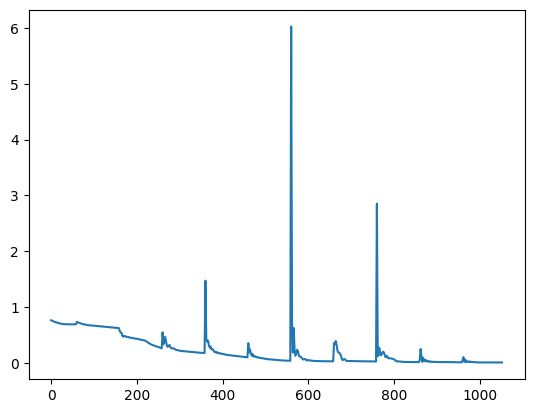

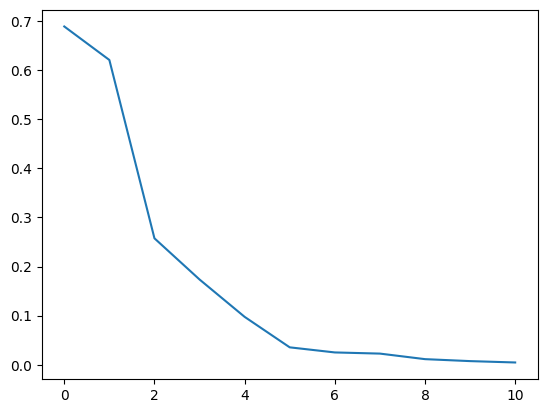

finall losses= [0.6884335279464722, 0.6202845573425293, 0.257352352142334, 0.17357736825942993, 0.09753622114658356, 0.035506464540958405, 0.025128018110990524, 0.022769033908843994, 0.011483408510684967, 0.0074799335561692715, 0.004700999241322279]


In [4]:
import copy
import heapq

seed_everything(SEED)



# arr = np.array([[0.,5,], [2.,5.]])
# fit_exp(arr)



# Returns the best layers to add nodes to
#TODO: At the moment it uses a simple and kinda bad method of choosing node with highest magnitudes, could improve with a more thought out idea eg one where adding a neuron above would maximize it.
#TODO:  -  Also I'm pretty sure this method will love to expand 
# b = branch factor
# max_growth = the maximum number of nodes a branch is able to add in a single iteration
# p_mg = the probability of getting the maximum growth from an exponential distribution (clipped)
def get_expand_layers(model:MLP, b, max_growth, p_mg):
    # 1) Get weights with highest magnitude
    vertex_importances = []
    llayers = model.linear_idx[0: len(model.linear_idx)-1]; # We should avoid adding to the output layer

    l=0
    for layer in llayers:
        w_l = model.network[layer].weight # Weights for this layer
        layer_importance = torch.max( torch.flatten( torch.abs(w_l) ) ) # the score of the layer is the absolute value of the largest weight
        vertex_importances.append( [float(layer_importance), l] )
        l+=1

    # Probability distribution that favours layers with higher importance
    vimp = np.array(vertex_importances) # vertex importances
    verts = vimp[:,1].astype(int); p = vimp[:,0] # lower importance = higher probability
    softmax = p / np.sum(p) ; #np.exp(temperature*p) / np.sum(np.exp(temperature*p))

    # 2) Choose the number of nodes to add for each branch, over time it is more likely to add fewer nodes
    # If lambda = -1/c  ln(p), then the output will be >= c with probability at least p.
    # We can set it outputs it is >=5 as a certainty at the start, but this chance decreases over time
    c= max_growth
    beta = - c/ np.log(p_mg)
    n_new = np.round( np.clip(np.random.exponential(scale=beta, size=20), a_min=1, a_max=c) )
    # Choose the layers for each branch
    layers =  [np.random.choice(verts, size=int(n_new[i]), p=softmax ) for i in range(b)] # [  branch1: [layer1, layer1, layer2]    ]
    return layers


# TODO: max_params = the maximum number of parameters being trained at a given time. 
# - to prevent memory useage exploding too much
# We'll do max_nodes instead actually for now cos thats easier and there's also implications on whether the former would prioritise smaller or bigger models that I don't want to think about rn
# stochastic beam search
# PARAMS
# capacity = the maximum number of nodes being expanded in the search tree
# b = the branch factor.
# cfg = the configurations for how each node is trained.
def beam_train(model: MLP, cfg, X_tr, y_tr,  max_iterations=10, b=2, capacity=10):
    # 1) Copy the model
    model0 = copy.deepcopy(model)
    model0.train_model(cfg, X_tr, y_tr) # Train the current network
 
    frontier = []
    heapq.heappush(frontier, (1.0, model0)) # Use a heap for the priority queue

    # print("queue=", frontier)
    best_model = (1.0, model0)

    n_iterations = max_iterations
    i=0
    while len(frontier) > 0 and i<n_iterations:
        print("\ni=", i)
        print("frontier=", len(frontier) )
        print("frontier=", [x[0] for x in frontier])

        #?---------------------------------------------------------- ?#
        #? Memory killer - Keep dropping bad states until we're at the required capacity
        n_deletions = len(frontier) - capacity
        k_largest = set( heapq.nlargest(n_deletions, frontier) )
        frontier = [x for x in frontier if x not in k_largest]
        heapq.heapify(frontier)
        #?---------------------------------------------------------- ?#


        current: MLP = heapq.heappop(frontier)[1] # A trained network
        next_layers = get_expand_layers(current, b, 5, 0.6)

     
        # 2) Create the child nodes
        for l in next_layers:
            #TODO: Here u should compare continuing from current initialization, or from random initialization
            #--------------------------------------------
            # Start from current initialization approach
            #--------------------------------------------
            new_model = copy.deepcopy(current)

            # Add the new nodes
            new_model.add_units(l)

            # Train the model to get its f-score. f=current_loss + estimate = g + estimate
            gscore = new_model.train_model(cfg, X_tr, y_tr)

            #?---------- Calculate the f-score ----------------
            # # a) Model a curve from the recent previous losses
            # num_samples = 4 
            # history = np.array(new_model.loss_history); n = len(history)
            # samples = history[-num_samples: ]
            fscore = gscore
            print("loss history=", new_model.final_loss_history)
            # fscore = new_model.get_fscore(n_iterations)  # get_fscore(new_model, max_iterations)
            print("fscore=", fscore)
            #?-----------------------------------------------


            print(l, "loss=", fscore)
            # frontier.append( new_model)
            heapq.heappush(frontier, (fscore, new_model))

            # Keep track of the current best model
            if fscore < best_model[0]:
                best_model = (fscore, new_model)

        i += 1

    # Return the best model
    loss, best = best_model
    return best, loss



cfg = {"max_epoch": 100, "criterion": "BCE", "lr": 0.01, "patience": 20}
model = MLP(in_dim=2, hidden=(2,3,2,2), out_dim=1)  # hidden=(50,2)
# result = beam_train(model, max_nodes=20)

# loss1= model.train_model(cfg, X_train, y_train)



#--------------
model_trained, final_loss= beam_train(model, cfg, X_train, y_train, max_iterations=10)


test_make_moons(model_trained, X_train, y_train)

# print("Dimensions:")
# print(model_trained)
print("Final loss=", final_loss)
print("loss history=", model_trained.loss_history)

model_trained.plot_loss()
model_trained.plot_final_loss()
print("finall losses=", model_trained.final_loss_history)
#--------------





    

# get_fscore(2, 10)
            



